In [22]:
# =========================
# ETAPE 1: Charger les données
# =========================

import pandas as pd
import numpy as np

# Charger le fichier CSV
df = pd.read_csv("calories.csv")

# Afficher un aperçu
print("Aperçu (5 premières lignes) :")
print(df.head())

# Afficher les informations générales
print("\nInfos dataset :")
print(df.info())

# Afficher les noms des colonnes
print("\nColonnes :")
print(list(df.columns))

# Vérifier les valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df.isna().sum())

Aperçu (5 premières lignes) :
   age  weight_kg  height_cm  duration_min  steps  heart_rate  intensity  \
0   56         78        164            81  13964         110          3   
1   36         72        160            84  13636         113          3   
2   19         73        193            39   8949          91          1   
3   29         71        193            58  10666         148          3   
4   45         65        164            71   4734         151          3   

   calories  
0    1428.0  
1    1429.5  
2     344.5  
3    1110.0  
4    1299.5  

Infos dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           500 non-null    int64  
 1   weight_kg     500 non-null    int64  
 2   height_cm     500 non-null    int64  
 3   duration_min  500 non-null    int64  
 4   steps         500 non-null    int64  
 5   he

In [19]:
# --------------------------
# 2) Détecter la TARGET (y)
# --------------------------
# On cherche une colonne qui ressemble à "calories" / "kcal"
target_candidates = [c for c in df.columns if ("calor" in c.lower()) or ("kcal" in c.lower())]

if not target_candidates:
    # Si rien trouvé, on affiche un message clair
    raise ValueError(
        "❌ Je ne trouve pas de colonne 'calories'.\n"
        "➡️ Vérifie les colonnes affichées ci-dessus et renomme la target (ex: 'Calories')."
    )

TARGET = target_candidates[0]  # on prend la 1ère candidate trouvée
print(f"\n✅ TARGET choisie automatiquement : {TARGET}")

# Séparer X (features) et y (target)
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Remplacer les cellules vides par NaN (optionnel)
X = X.replace(r"^\s*$", np.nan, regex=True)


✅ TARGET choisie automatiquement : calories


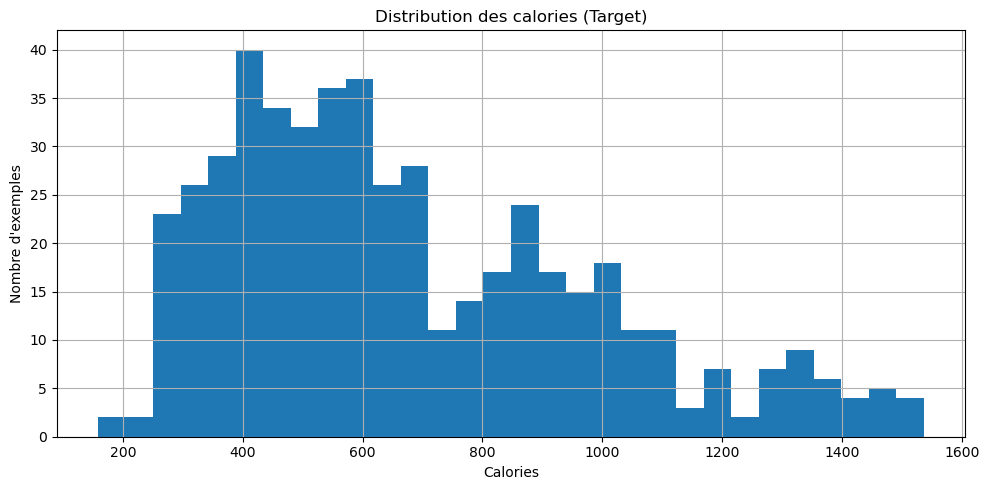

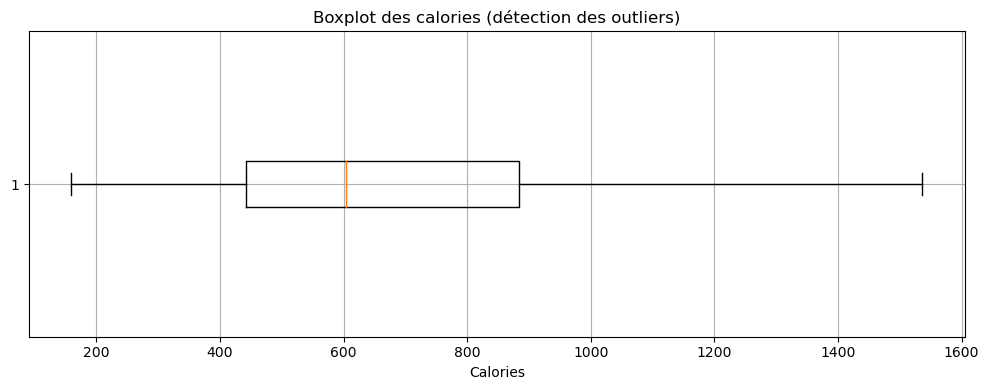

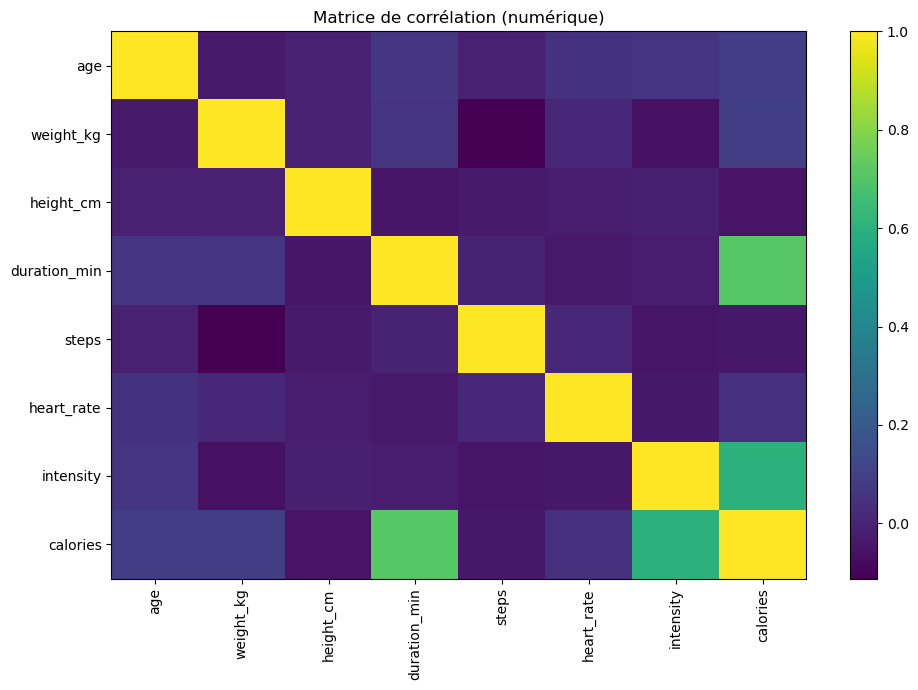

In [14]:
# =========================
# ETAPE 3: Visualisation 
# =========================

import matplotlib.pyplot as plt

# 1) Distribution de la target (calories)
plt.figure(figsize=(10, 5))
plt.hist(y.dropna(), bins=30)
plt.title("Distribution des calories (Target)")
plt.xlabel("Calories")
plt.ylabel("Nombre d'exemples")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Boxplot de la target (repérer valeurs extrêmes)
plt.figure(figsize=(10, 4))
plt.boxplot(y.dropna(), vert=False)
plt.title("Boxplot des calories (détection des outliers)")
plt.xlabel("Calories")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) Corrélations (uniquement colonnes numériques)
num_df = df.select_dtypes(include=["int64", "float64", "int32", "float32"])
if num_df.shape[1] >= 2:
    corr = num_df.corr(numeric_only=True)

    plt.figure(figsize=(10, 7))
    plt.imshow(corr, aspect="auto")
    plt.title("Matrice de corrélation (numérique)")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Pas assez de colonnes numériques pour une corrélation.")

📌 Résultats:
RMSE = 104.85
R²   = 0.900


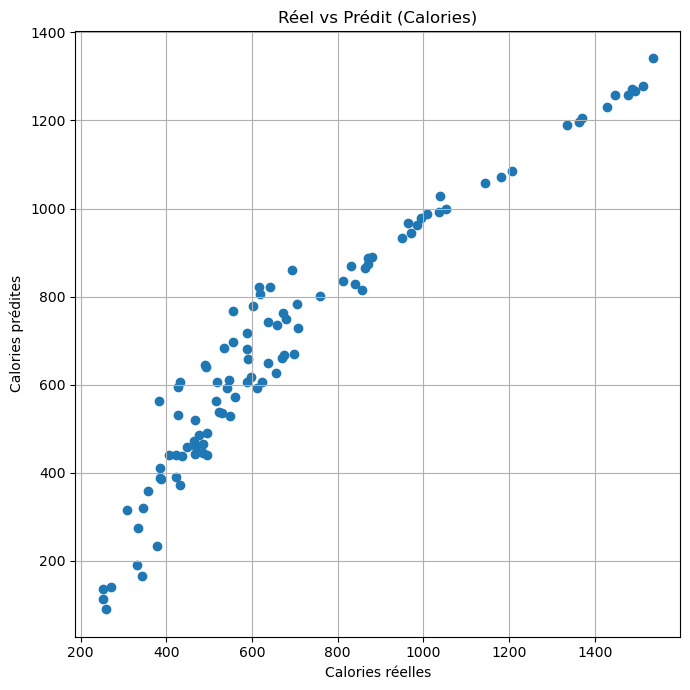

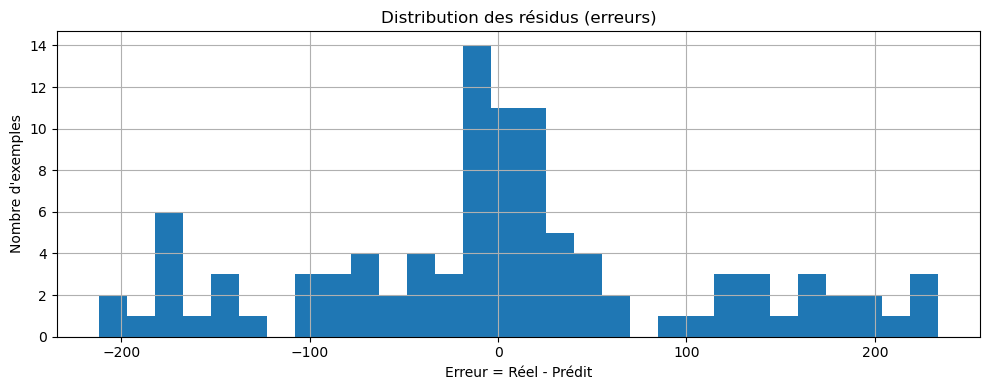

In [15]:
# =========================
# ETAPE 5: Evaluation
# =========================

from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("📌 Résultats:")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}")

# Graphique pro : Réel vs Prédit
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred)
plt.title("Réel vs Prédit (Calories)")
plt.xlabel("Calories réelles")
plt.ylabel("Calories prédites")
plt.grid(True)
plt.tight_layout()
plt.show()

# Graphique pro : Résidus (erreurs)
residuals = y_test - y_pred
plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=30)
plt.title("Distribution des résidus (erreurs)")
plt.xlabel("Erreur = Réel - Prédit")
plt.ylabel("Nombre d'exemples")
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# =========================
# ETAPE 6: Prédire sur un nouvel exemple
# =========================

def predire_calories(nouvelle_ligne: dict) -> float:
    """
    nouvelle_ligne : dictionnaire avec les mêmes colonnes que X.
    Exemple:
    {
      "Activity": "Running",
      "Duration": 30,
      "Weight": 70,
      "Heart_Rate": 140
    }
    """
    ligne_df = pd.DataFrame([nouvelle_ligne])
    return float(model.predict(ligne_df)[0])

# Exemple automatique (prend des valeurs réalistes depuis ton dataset)
example = {}
for col in X.columns:
    if col in categorical_features:
        example[col] = str(X[col].dropna().iloc[0]) if X[col].dropna().shape[0] else "Unknown"
    else:
        example[col] = float(X[col].dropna().median()) if X[col].dropna().shape[0] else 0.0

print("Exemple utilisé :", example)
print("🔥 Calories estimées :", predire_calories(example))

Exemple utilisé : {'age': 39.0, 'weight_kg': 74.5, 'height_cm': 174.0, 'duration_min': 47.0, 'steps': 8748.0, 'heart_rate': 134.0, 'intensity': 2.0}
🔥 Calories estimées : 682.5299976106731
